In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')
# 시드 고정 (재현성)
np.random.seed(42)

In [3]:
X_clf , y_clf = make_classification(
    n_samples=400 , n_features=2 , random_state=42,
    n_informative=2 , n_redundant=0 ,n_clusters_per_class=1 , class_sep=1.5
)
scaler = StandardScaler()
X_clf = scaler.fit_transform(X_clf)

x_train , x_test , y_train , y_test = train_test_split(X_clf,y_clf,random_state=42,stratify=y_clf)
x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.LongTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.LongTensor(y_test)

In [4]:
class BinaryClassfier(nn.Module):
    def __init__(self)->None:
        super().__init__()
        self.fc1 = nn.Linear(2,16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16,1)
        #self.sigmoid = nn.Sigmoid()
    def forward(self,x):
        x = self.relu( self.fc1(x) )
        output = self.fc2(x)
        return output
model = BinaryClassfier()
model

BinaryClassfier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

In [5]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(),lr=0.01, momentum=0)
x_train_dataset = TensorDataset(x_train_t , y_train_t)
x_train_loader = DataLoader(x_train_dataset , batch_size=32 , shuffle=True)

In [6]:
for x,y in x_train_loader:
    print(x.shape , y.shape)
    print(y.unsqueeze(-1).shape)
    break

torch.Size([32, 2]) torch.Size([32])
torch.Size([32, 1])


In [7]:
epochs = 100
train_losses , train_accs = [],[]
for epoch in range(epochs):
    total_loss , total_acc = 0.0 , 0.0
    for x,y in x_train_loader :
        # 가중치 초기화
        optimizer.zero_grad()
        # forward
        pred = model(x)
        # loss - shape 맞추기: y를 float로 변환하고 unsqueeze
        y_float = y.float().unsqueeze(-1)
        loss = criterion(pred, y_float)
        # backward
        loss.backward()
        # 가중치 업데이트
        optimizer.step()
        total_loss += loss.item()
        # accuracy 계산
        pred_class = (torch.sigmoid(pred) > 0.5).float() # 정확도 계산: sigmoid를 거친 확률값 필요
        total_acc += (pred_class == y_float).sum().item() / len(y)

    avg_loss = total_loss / len(x_train_loader)
    avg_acc = total_acc / len(x_train_loader)
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] - 평균 Loss: {avg_loss:.4f} , 평균 acc : {avg_acc:.4f}")

Epoch [ 10/100] - 평균 Loss: 0.6170 , 평균 acc : 0.9062
Epoch [ 20/100] - 평균 Loss: 0.4788 , 평균 acc : 0.9323
Epoch [ 30/100] - 평균 Loss: 0.3778 , 평균 acc : 0.9469
Epoch [ 40/100] - 평균 Loss: 0.3120 , 평균 acc : 0.9500
Epoch [ 50/100] - 평균 Loss: 0.2571 , 평균 acc : 0.9500
Epoch [ 60/100] - 평균 Loss: 0.2246 , 평균 acc : 0.9500
Epoch [ 70/100] - 평균 Loss: 0.2028 , 평균 acc : 0.9479
Epoch [ 80/100] - 평균 Loss: 0.1785 , 평균 acc : 0.9563
Epoch [ 90/100] - 평균 Loss: 0.1621 , 평균 acc : 0.9563
Epoch [100/100] - 평균 Loss: 0.1559 , 평균 acc : 0.9563


Test Accuracy: 0.9200


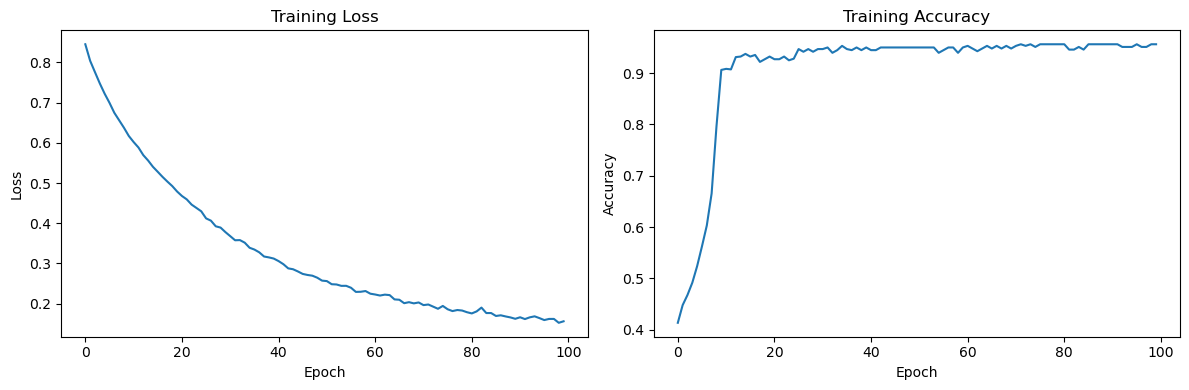

In [8]:
# 평가 모드
model.eval()
with torch.no_grad():
    test_pred = model(x_test_t)
    test_pred_class = (torch.sigmoid(test_pred) > 0.5).float().squeeze()
    test_acc = (test_pred_class == y_test_t).float().mean().item()
    print(f"Test Accuracy: {test_acc:.4f}")

# 학습 과정 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [9]:
y_test_t.shape, test_pred.shape

(torch.Size([100]), torch.Size([100, 1]))

# 회귀

In [10]:
# 회귀 데이터 생성
import numpy as np
X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=5,
    n_informative=5,
    noise=20.0,
    random_state=42
)

# 데이터 정규화
scaler_X_reg = StandardScaler()
X_reg = scaler_X_reg.fit_transform(X_reg)

scaler_y_reg = StandardScaler()
y_reg = scaler_y_reg.fit_transform(y_reg.reshape(-1, 1)).flatten()

# 학습/테스트 분할 (80/20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_reg_train_tensor = torch.FloatTensor(X_reg_train)
y_reg_train_tensor = torch.FloatTensor(y_reg_train).reshape(-1, 1)
X_reg_test_tensor = torch.FloatTensor(X_reg_test)
y_reg_test_tensor = torch.FloatTensor(y_reg_test).reshape(-1, 1)

print(f"회귀 데이터셋 생성 완료")
print(f"훈련 데이터: {X_reg_train_tensor.shape}")
print(f"테스트 데이터: {X_reg_test_tensor.shape}")
print(f"목표값 범위: [{y_reg.min():.4f}, {y_reg.max():.4f}]")

회귀 데이터셋 생성 완료
훈련 데이터: torch.Size([240, 5])
테스트 데이터: torch.Size([60, 5])
목표값 범위: [-2.4866, 2.6997]


In [11]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 16)
        self.fc2 = nn.Linear(16, 1)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))  
        output = self.fc2(x)
        return output
model_reg =  RegressionModel()

In [12]:
# SGD 최적화기 설정 (회귀용)
criterion_reg = nn.MSELoss()  # 회귀 손실함수: MSE
optimizer_sgd_reg = optim.SGD(model_reg.parameters(), lr=0.01, momentum=0)

# DataLoader (batch_size=1 for true SGD)
reg_dataset = TensorDataset(X_reg_train_tensor, y_reg_train_tensor)
reg_loader = DataLoader(reg_dataset, batch_size=1, shuffle=True)

# 훈련 루프
num_epochs = 150
train_losses_reg = []
train_r2_scores = []

from tqdm import tqdm
for epoch in tqdm(range(num_epochs)):
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    for X_batch, y_batch in reg_loader:
        optimizer_sgd_reg.zero_grad()
        # Forward pass
        outputs = model_reg(X_batch)      
        # Backward pass + SGD 업데이트    
        loss = criterion_reg(outputs, y_batch)    
        loss.backward()
        optimizer_sgd_reg.step()

        total_loss += loss.item() * X_batch.size(0)  # torch size는 shape
        
        # R² 점수 계산을 위한 데이터 수집
        with torch.no_grad():
            all_predictions.append(outputs.item())
            all_targets.append(y_batch.item())
    
    avg_loss = total_loss / len(reg_loader)
    r2 = r2_score(all_targets, all_predictions)
    train_losses_reg.append(avg_loss)
    train_r2_scores.append(r2)
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}, R²: {r2:.4f}")

print("\n회귀 모델 훈련 완료!")

 21%|██▏       | 32/150 [00:03<00:10, 11.41it/s]

Epoch [30/150] Loss: 0.0292, R²: 0.9713


 41%|████▏     | 62/150 [00:05<00:07, 11.27it/s]

Epoch [60/150] Loss: 0.0279, R²: 0.9727


 61%|██████▏   | 92/150 [00:08<00:05, 11.12it/s]

Epoch [90/150] Loss: 0.0268, R²: 0.9737


 81%|████████▏ | 122/150 [00:11<00:02, 11.52it/s]

Epoch [120/150] Loss: 0.0252, R²: 0.9753


100%|██████████| 150/150 [00:13<00:00, 11.17it/s]

Epoch [150/150] Loss: 0.0245, R²: 0.9760

회귀 모델 훈련 완료!


In [14]:
# 테스트 데이터에 대한 평가
with torch.no_grad():
    y_pred_reg = model_reg(X_reg_test_tensor)
    test_mse = mean_squared_error(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_r2 = r2_score(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_rmse = np.sqrt(test_mse)

print("\n[회귀 문제 결과]")
print(f"테스트 MSE: {test_mse:.4f}")
print(f"테스트 RMSE: {test_rmse:.4f}")
print(f"테스트 R²: {test_r2:.4f}")


[회귀 문제 결과]
테스트 MSE: 0.0489
테스트 RMSE: 0.2211
테스트 R²: 0.9469
